In [2]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import importlib
import experiment_utils

importlib.reload(experiment_utils)

from experiment_utils import (
    MLPClassifierLeakyReLU,
    MLPClassifierGELU,
    run_one_experiment,
    run,
    save_result_activation_change
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema_v2.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df["date"] = pd.to_datetime(df["date"], format="mixed")

df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
df.head()

(1239, 49)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,...,away_form_sma7,away_form_ema50,away_form_ema33,away_form_ema25,form_diff_sma3,form_diff_sma5,form_diff_sma7,form_diff_ema50,form_diff_ema33,form_diff_ema25
0,2022-01-27,Jamaica,Mexico,1.0,2.0,FIFA World Cup qualification,Kingston,Jamaica,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-27,United Arab Emirates,Syria,2.0,0.0,FIFA World Cup qualification,Dubai,United Arab Emirates,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-27,Honduras,Canada,0.0,2.0,FIFA World Cup qualification,San Pedro Sula,Honduras,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-27,Costa Rica,Panama,1.0,0.0,FIFA World Cup qualification,San José,Costa Rica,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-27,Lebanon,South Korea,0.0,1.0,FIFA World Cup qualification,Sidon,Lebanon,0,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
best_ema = "ema25"
best_sma = "sma5"


features = [
    "home_rank",
    "away_rank",
    "home_elo",
    "away_elo",
    f"home_form_{best_ema}",
    f"away_form_{best_ema}",
    f"home_form_{best_sma}",
    f"away_form_{best_sma}",
]

target = "result"

features

['home_rank',
 'away_rank',
 'home_elo',
 'away_elo',
 'home_form_ema25',
 'away_form_ema25',
 'home_form_sma5',
 'away_form_sma5']

In [5]:
print("Broj redova pre uklanjanja NaN vrednosti:", len(df))
print()
print("NaN vrednosti u feature kolonama:")
print(df[features].isna().sum())

df = df.dropna(subset=features + [target]).reset_index(drop=True)

print()
print("Broj redova posle uklanjanja NaN vrednosti:", len(df))
print()
print("Provera NaN vrednosti posle filtriranja:")
print(df[features].isna().sum())

df[features + [target]].head()

Broj redova pre uklanjanja NaN vrednosti: 1239

NaN vrednosti u feature kolonama:
home_rank            0
away_rank            0
home_elo             0
away_elo             0
home_form_ema25     98
away_form_ema25    108
home_form_sma5      98
away_form_sma5     108
dtype: int64

Broj redova posle uklanjanja NaN vrednosti: 1110

Provera NaN vrednosti posle filtriranja:
home_rank          0
away_rank          0
home_elo           0
away_elo           0
home_form_ema25    0
away_form_ema25    0
home_form_sma5     0
away_form_sma5     0
dtype: int64


,home_rank,away_rank,home_elo,away_elo,home_form_ema25,away_form_ema25,home_form_sma5,away_form_sma5,result
0,14.0,49.0,1839.0,1743.0,3.0,3.0,3.0,3.0,0
1,40.0,11.0,1784.0,1858.0,3.0,3.0,3.0,3.0,1
2,76.0,70.0,1604.0,1466.0,0.0,0.0,0.0,0.0,-1
3,63.0,57.0,1627.0,1578.0,0.0,0.0,0.0,0.0,1
4,17.0,59.0,1847.0,1801.0,3.0,3.0,3.0,3.0,1


In [6]:
X = df[features].values

label_map = {
    -1: 0,   # away win
     0: 1,   # draw
     1: 2    # home win
}

y = df[target].map(label_map).values

print("Label mapping:")
print("-1 -> 0  away win")
print(" 0 -> 1  draw")
print(" 1 -> 2  home win")

Label mapping:
-1 -> 0  away win
 0 -> 1  draw
 1 -> 2  home win


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (888, 8)
X_test: (222, 8)
y_train: (888,)
y_test: (222,)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("Tensor shapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

Tensor shapes:
X_train_tensor: torch.Size([888, 8])
y_train_tensor: torch.Size([888])
X_test_tensor: torch.Size([222, 8])
y_test_tensor: torch.Size([222])


In [10]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model_lrelu = MLPClassifierLeakyReLU(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_lrelu.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8532 | val loss = 0.7281 | val acc = 0.6798
Epoch 100/1000 | train loss = 0.8412 | val loss = 0.7293 | val acc = 0.6685
Epoch 150/1000 | train loss = 0.8137 | val loss = 0.7245 | val acc = 0.6629
Epoch 200/1000 | train loss = 0.7842 | val loss = 0.7250 | val acc = 0.6461
Epoch 250/1000 | train loss = 0.7970 | val loss = 0.7253 | val acc = 0.6292
Epoch 300/1000 | train loss = 0.7779 | val loss = 0.7326 | val acc = 0.6348
Epoch 350/1000 | train loss = 0.7614 | val loss = 0.7308 | val acc = 0.6292
Epoch 400/1000 | train loss = 0.7231 | val loss = 0.7468 | val acc = 0.6180
Epoch 450/1000 | train loss = 0.7378 | val loss = 0.7505 | val acc = 0.6348
Epoch 500/1000 | train loss = 0.7170 | val loss = 0.7439 | val acc = 0.6067
Epoch 550/1000 | train loss = 0.7296 | val loss = 0.7427 | val acc = 0.6011
Epoch 600/1000 | train loss = 0.7265 | val loss = 0.7597 | val acc = 0.6348
Epoch 650/1000 | train loss = 0.7152 | val loss = 0.7516 | val acc = 0.6236
Epoch 700/100

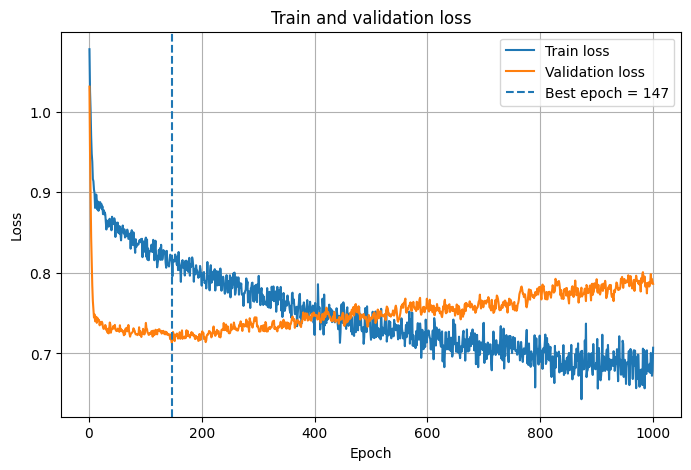

0.6486486486486487

In [11]:
run_one_experiment(
    model=model_lrelu,
    criterion=criterion,
    optimizer=optimizer,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
)

In [12]:
best_num_epochs = 147

summary, results_df = run(
    model_class=MLPClassifierLeakyReLU,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_runs=10,
    num_epochs=best_num_epochs,
    batch_size=16,
    learning_rate=0.001
)

Run 1/10
Accuracy: 0.6486 | Precision: 0.5768 | Recall: 0.5715 | Specificity: 0.8059 | F1: 0.5608

Run 2/10
Accuracy: 0.6757 | Precision: 0.6662 | Recall: 0.5817 | Specificity: 0.8137 | F1: 0.5584

Run 3/10
Accuracy: 0.6757 | Precision: 0.6198 | Recall: 0.5838 | Specificity: 0.8143 | F1: 0.5610

Run 4/10
Accuracy: 0.6802 | Precision: 0.6428 | Recall: 0.5929 | Specificity: 0.8182 | F1: 0.5781

Run 5/10
Accuracy: 0.6712 | Precision: 0.6187 | Recall: 0.5827 | Specificity: 0.8116 | F1: 0.5656

Run 6/10
Accuracy: 0.6486 | Precision: 0.5548 | Recall: 0.5635 | Specificity: 0.8040 | F1: 0.5432

Run 7/10
Accuracy: 0.6441 | Precision: 0.5595 | Recall: 0.5480 | Specificity: 0.7950 | F1: 0.5275

Run 8/10
Accuracy: 0.6577 | Precision: 0.6030 | Recall: 0.5636 | Specificity: 0.8045 | F1: 0.5292

Run 9/10
Accuracy: 0.6712 | Precision: 0.6389 | Recall: 0.5890 | Specificity: 0.8154 | F1: 0.5660

Run 10/10
Accuracy: 0.6667 | Precision: 0.6037 | Recall: 0.5776 | Specificity: 0.8114 | F1: 0.5600

Summary o

In [13]:
save_result_activation_change(
    experiment_name=f"Experiment_3-3_v2_points_ranks_{best_sma.upper()}_{best_ema.upper()}_LeakyReLU",
    summary=summary
)


Saved result for Experiment_3-3_v2_points_ranks_SMA5_EMA25_LeakyReLU
File: ../results/experiment_summary_activation_change.csv


In [15]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model_gelu = MLPClassifierGELU(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_gelu.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8579 | val loss = 0.7264 | val acc = 0.6854
Epoch 100/1000 | train loss = 0.8493 | val loss = 0.7317 | val acc = 0.6742
Epoch 150/1000 | train loss = 0.8216 | val loss = 0.7205 | val acc = 0.6573
Epoch 200/1000 | train loss = 0.8082 | val loss = 0.7229 | val acc = 0.6685
Epoch 250/1000 | train loss = 0.8093 | val loss = 0.7176 | val acc = 0.6573
Epoch 300/1000 | train loss = 0.8050 | val loss = 0.7281 | val acc = 0.6461
Epoch 350/1000 | train loss = 0.7887 | val loss = 0.7322 | val acc = 0.6461
Epoch 400/1000 | train loss = 0.7703 | val loss = 0.7431 | val acc = 0.6348
Epoch 450/1000 | train loss = 0.7491 | val loss = 0.7546 | val acc = 0.6517
Epoch 500/1000 | train loss = 0.7379 | val loss = 0.7557 | val acc = 0.6461
Epoch 550/1000 | train loss = 0.7230 | val loss = 0.7681 | val acc = 0.6517
Epoch 600/1000 | train loss = 0.7474 | val loss = 0.7685 | val acc = 0.6573
Epoch 650/1000 | train loss = 0.7268 | val loss = 0.7939 | val acc = 0.6629
Epoch 700/100

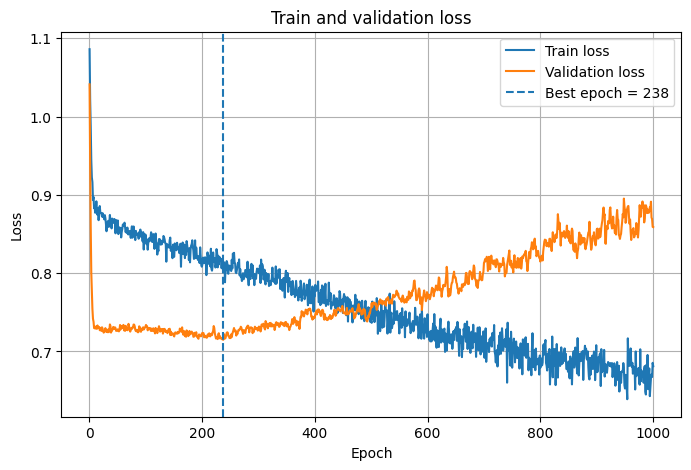

0.6306306306306306

In [16]:
run_one_experiment(
    model=model_gelu,
    criterion=criterion,
    optimizer=optimizer,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
)

In [17]:
best_num_epochs = 238

summary, results_df = run(
    model_class=MLPClassifierGELU,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_runs=10,
    num_epochs=best_num_epochs,
    batch_size=16,
    learning_rate=0.001
)

Run 1/10
Accuracy: 0.6306 | Precision: 0.5550 | Recall: 0.5532 | Specificity: 0.7957 | F1: 0.5403

Run 2/10
Accuracy: 0.6261 | Precision: 0.5381 | Recall: 0.5441 | Specificity: 0.7946 | F1: 0.5287

Run 3/10
Accuracy: 0.6712 | Precision: 0.6432 | Recall: 0.5808 | Specificity: 0.8126 | F1: 0.5563

Run 4/10
Accuracy: 0.6667 | Precision: 0.6096 | Recall: 0.5836 | Specificity: 0.8118 | F1: 0.5741

Run 5/10
Accuracy: 0.6441 | Precision: 0.5778 | Recall: 0.5787 | Specificity: 0.8057 | F1: 0.5723

Run 6/10
Accuracy: 0.6171 | Precision: 0.5456 | Recall: 0.5523 | Specificity: 0.7945 | F1: 0.5471

Run 7/10
Accuracy: 0.6216 | Precision: 0.5300 | Recall: 0.5410 | Specificity: 0.7932 | F1: 0.5272

Run 8/10
Accuracy: 0.6712 | Precision: 0.6415 | Recall: 0.5829 | Specificity: 0.8160 | F1: 0.5556

Run 9/10
Accuracy: 0.6577 | Precision: 0.5687 | Recall: 0.5554 | Specificity: 0.8043 | F1: 0.5082

Run 10/10
Accuracy: 0.6486 | Precision: 0.5600 | Recall: 0.5572 | Specificity: 0.8027 | F1: 0.5382

Summary o

In [18]:
save_result_activation_change(
    experiment_name=f"Experiment_3-3_v2_points_ranks_{best_sma.upper()}_{best_ema.upper()}_GELU",
    summary=summary
)


Saved result for Experiment_3-3_v2_points_ranks_SMA5_EMA25_GELU
File: ../results/experiment_summary_activation_change.csv
